In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

My Try:

In [1]:
from pydantic import BaseModel,Field
from typing_extensions import Literal
from langchain_core.messages import HumanMessage,SystemMessage
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display

In [18]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")
llm2=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
result=llm.invoke("Hello")
result

AIMessage(content='<think>\nAlright, the user just said "Hello". I need to respond appropriately. Since this is the first message, I should greet them back and offer assistance. I should keep it friendly and open-ended to encourage them to ask questions or share what they need help with. Let me make sure the response is welcoming and clear.\n</think>\n\nHello! How can I assist you today? If you have any questions or need help with something, feel free to ask! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 9, 'total_tokens': 105, 'completion_time': 0.18052412, 'completion_tokens_details': None, 'prompt_time': 0.000514153, 'prompt_tokens_details': None, 'queue_time': 0.160814325, 'total_time': 0.181038273}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e87a0-296a-7ce1-9239-2df827175e75-0', tool_c

In [19]:
class Evaluate(BaseModel):
    status:Literal["Pass","Fail"]=Field(description="The evaluation result, either 'Pass' or 'Fail'.")
    feedback:str=Field(description="Detailed feedback on the evaluation result.")

evaluator=llm2.with_structured_output(Evaluate)

class State(TypedDict):
    input:str
    status:str
    output:str

In [ ]:
def llm_call_generate(state:State):
    """Write a joke"""
    print("Joke generation has been called")
    result=llm.invoke(state["input"])
    return {"output": result}

def llm_call_router(state:State):
    """Evaluate the joke and route to the appropriate next step"""
    print("Joke evaluation has been called")
    decision=evaluator.invoke(
        [
            SystemMessage(content="You are a joke evaluator. You will be given a joke and you need to evaluate it based on its humor and creativity. If the joke is funny and creative, you should return 'Pass'. If the joke is not funny or lacks creativity, you should return 'Fail' and give a short and appropriate feedback."),
            HumanMessage(content=f"Evaluate the following joke: {state['output']}"),
        ]
    )
    return {"status": decision.status, "feedback": decision.feedback}

def accepted(state:State):
    """Print the accepted joke"""
    print(f"Accepted joke: {state['output']}")

In [21]:
def route_decision(state:State):
    if state["status"]=="Pass":
        return "accepted"
    print("Joke has been rejected. Feedback from evaluator:", state["feedback"])
    return "rejected"

In [22]:
router_builder=StateGraph(State)

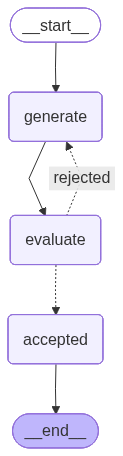

In [23]:
router_builder.add_node("generate", llm_call_generate)
router_builder.add_node("evaluate", llm_call_router)
router_builder.add_node("accepted", accepted)

router_builder.add_edge(START,"generate")
router_builder.add_edge("generate","evaluate")
router_builder.add_conditional_edges(
    "evaluate",
    route_decision,
    {
        "accepted":"accepted",
        "rejected":"generate"
    }
)
router_builder.add_edge("accepted", END)

router_workflow=router_builder.compile()
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [27]:
state=router_workflow.invoke({"input":"Write a joke about Robots"})
print(state["output"])

Joke generation has been called
Joke evaluation has been called
Accepted joke: content='<think>\nOkay, the user wants a joke about robots. Let me think... What\'s a common theme in robot jokes? Maybe something about them being literal or taking things literally. Oh, right, robots often take human expressions literally.\n\nHmm, maybe start with a setup where a robot is told to take something seriously. Wait, the phrase "take it seriously" could be a good one. If a robot takes it literally, it might try to weigh the problem. Then the punchline could be about the robot not understanding the metaphor. Let me structure that.\n\nSo, the joke could go like this: A robot tells another robot, "I\'m going to take this problem seriously." The other one asks how, and the first says, "I\'m going to weigh it down with all my weight." Wait, that\'s not quite right. Maybe the first robot says, "I\'m going to weigh it down with all my weight," but the other one says, "But that\'s not how \'take it seri

Krishnaik:

In [28]:
class KState(TypedDict):
    joke:str
    topic:str
    feedback:str
    funny_or_not:str

In [29]:
class Feedback(BaseModel):
    grade:Literal["funny","not funny"]=Field(description="Decide if the joke is funny or not")
    feedback:str=Field(description="If the joke is not funny, provide feedback on how to improve it")

kevaluator=llm2.with_structured_output(Feedback)

In [30]:
def llm_call_generator(state:KState):
    """LLM gegerates a joke"""

    if state.get("feedback"):
        msg=llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg=llm.invoke(f"Write a joke about {state['topic']}")
    return{"joke":msg.content}

def evaluate(state:KState):
    """"LLM evaluates the joke"""

    grade=kevaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not":grade.grade,"feedback":grade.feedback}

def route_joke(state:KState):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"]=="funny":
        return "Accepted"
    elif state["funny_or_not"=="not funny"]:
        return "Rejected + Feedback"
